<a href="https://colab.research.google.com/github/bernadusprastyanto23/bernadus-dwi/blob/main/Pemeriksaan_Gas_ZA_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

sheet_id = "1QJc7WEiC31U1CPCyAmOlnoXqC5bj84-u4U5nsKcnv_8"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

In [ ]:
import pandas as pd

df = pd.read_csv(url, header=None) # Load without header, assuming an initial blank row

# Set the column headers using the second row (index 1) of the raw data
df.columns = df.iloc[1]

# Drop the first two rows (the blank row at index 0 and the header row at index 1)
df = df[2:].copy()

# Rename the columns to remove any leading/trailing spaces if present
df.columns = df.columns.str.strip()

# Convert 'hasil_pemeriksaan' to numeric, coercing errors to NaN
df['hasil_pemeriksaan'] = pd.to_numeric(df['hasil_pemeriksaan'], errors='coerce')

# Convert 'tanggal' to datetime objects, letting pandas infer the format
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

# Display the first few rows with correct headers to verify
print("Dataframe head after correct loading and date conversion:")
display(df.head())

# Calculate the average 'hasil_pemeriksaan' per 'lokasi_pemeriksaan'
average_per_area = df.groupby('lokasi_pemeriksaan')['hasil_pemeriksaan'].mean().round(3)

print("\nRata-rata hasil pemeriksaan per lokasi:")
display(average_per_area)

Dataframe head after correct loading and date conversion:


/tmp/ipykernel_8058/474405541.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')


1,tanggal,shift_type,lokasi_pemeriksaan,hasil_pemeriksaan,satuan,arah_angin
2,2026-06-12,sore,Depan SS Room,81,ppm,NaN
3,2026-06-12,sore,Barak Bawah,64,ppm,NaN
4,2026-06-12,sore,CCR ZA II,26,ppm,NaN
5,2026-06-13,malam,Depan SS Room,68,ppm,NaN
6,2026-06-13,malam,Barak Bawah,200,ppm,NaN



Rata-rata hasil pemeriksaan per lokasi:


,hasil_pemeriksaan
lokasi_pemeriksaan,
Barak Bawah,58.571
CCR ZA II,20.857
Depan SS Room,46.714


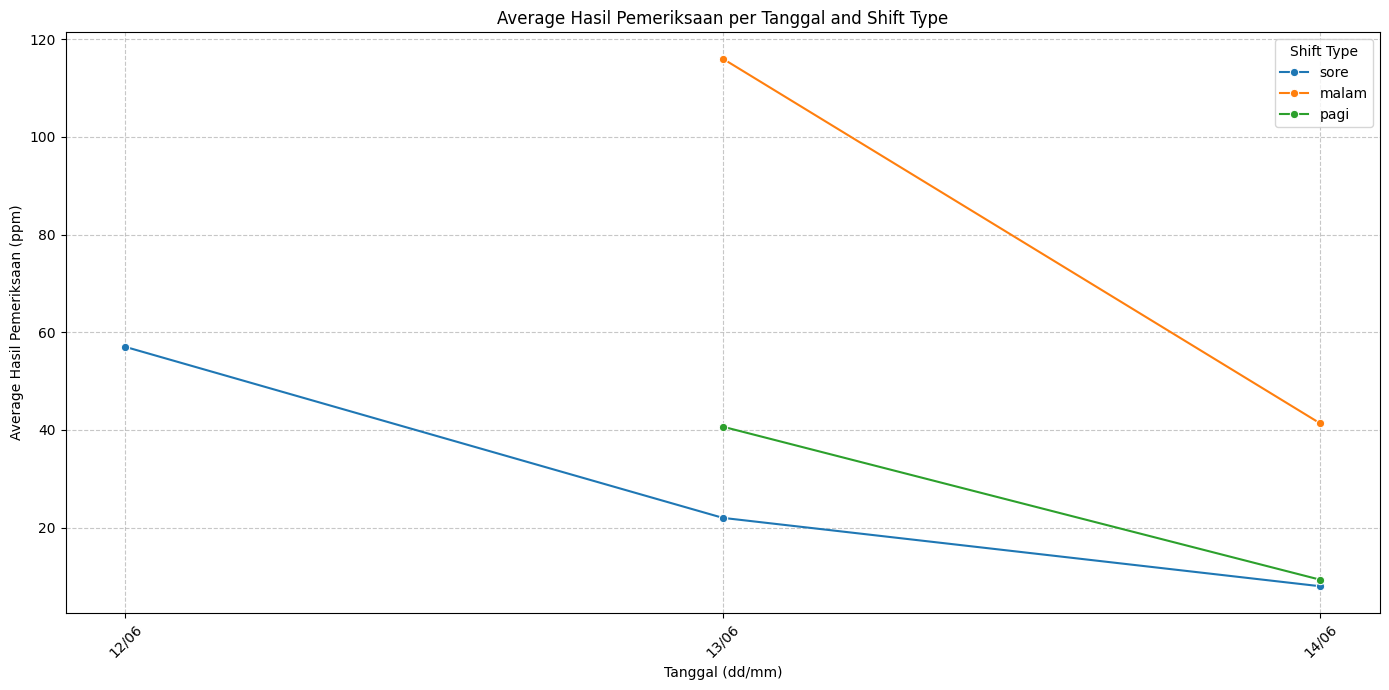

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows with NaT in 'tanggal' or NaN in 'hasil_pemeriksaan' or 'shift_type'
df_filtered = df.dropna(subset=['tanggal', 'hasil_pemeriksaan', 'shift_type']).copy()

# Group by 'tanggal' and 'shift_type' to get the average 'hasil_pemeriksaan'
df_shift_avg = df_filtered.groupby(['tanggal', 'shift_type'])['hasil_pemeriksaan'].mean().reset_index()

# Sort by date for correct line plot progression
df_shift_avg = df_shift_avg.sort_values(by='tanggal')

# Format 'tanggal' for display on the x-axis (dd/mm)
df_shift_avg['tanggal_display'] = df_shift_avg['tanggal'].dt.strftime('%d/%m')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_shift_avg, x='tanggal_display', y='hasil_pemeriksaan', hue='shift_type', marker='o')

plt.title('Average Hasil Pemeriksaan per Tanggal and Shift Type')
plt.xlabel('Tanggal (dd/mm)')
plt.ylabel('Average Hasil Pemeriksaan (ppm)')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Shift Type')
plt.tight_layout()
plt.show()

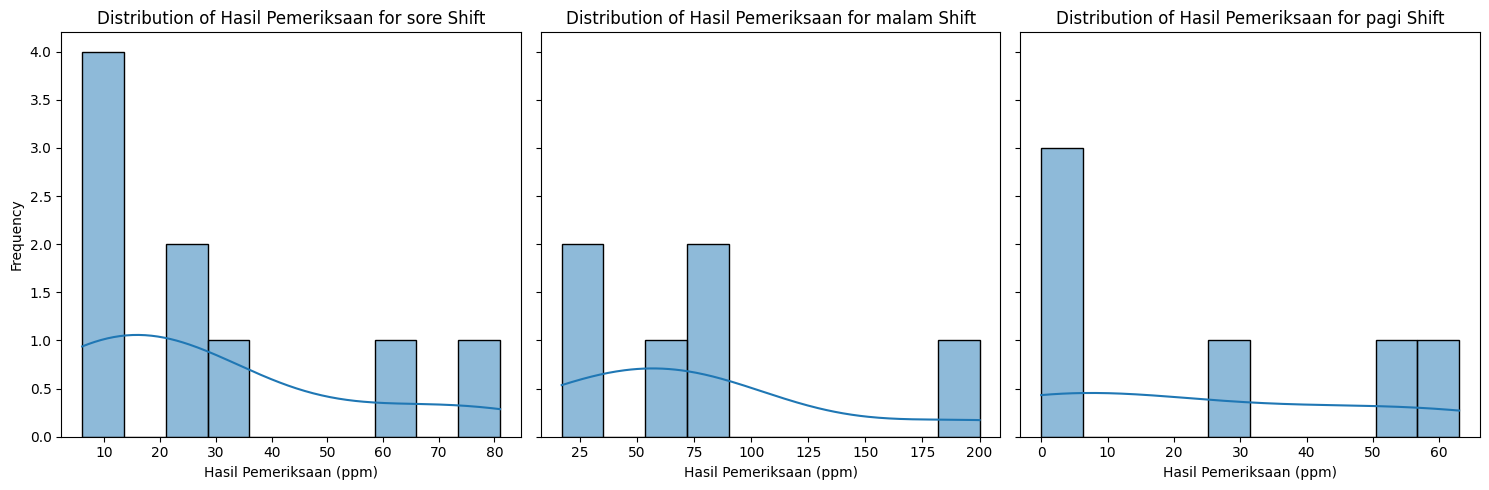

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows with NaN in 'hasil_pemeriksaan' or 'shift_type'
df_hist_filtered = df.dropna(subset=['hasil_pemeriksaan', 'shift_type']).copy()

# Get unique shift types
shift_types = df_hist_filtered['shift_type'].unique()

# Create subplots for each shift type
fig, axes = plt.subplots(1, len(shift_types), figsize=(15, 5), sharey=True)

if len(shift_types) == 1: # Handle case with a single subplot correctly
    axes = [axes]

for i, shift in enumerate(shift_types):
    sns.histplot(df_hist_filtered[df_hist_filtered['shift_type'] == shift]['hasil_pemeriksaan'], kde=True, ax=axes[i], bins=10)
    axes[i].set_title(f'Distribution of Hasil Pemeriksaan for {shift} Shift')
    axes[i].set_xlabel('Hasil Pemeriksaan (ppm)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

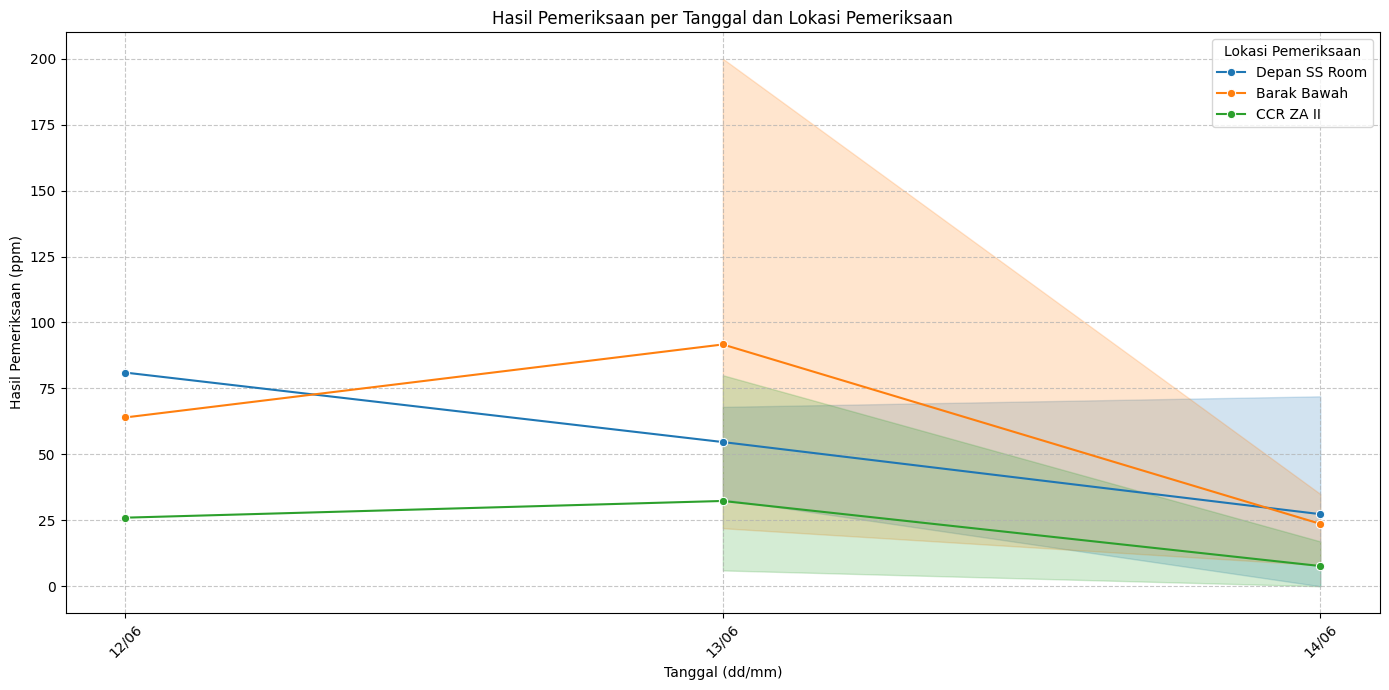

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out any rows where 'tanggal' or 'hasil_pemeriksaan' might be NaT or NaN after conversion
df_plot_all_locations = df.dropna(subset=['tanggal', 'hasil_pemeriksaan'])

# Sort by date for correct line plot progression
df_plot_all_locations = df_plot_all_locations.sort_values(by='tanggal')

# Format 'tanggal' for display on the x-axis (dd/mm)
df_plot_all_locations['tanggal_display'] = df_plot_all_locations['tanggal'].dt.strftime('%d/%m')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_plot_all_locations, x='tanggal_display', y='hasil_pemeriksaan', hue='lokasi_pemeriksaan', marker='o')

plt.title('Hasil Pemeriksaan per Tanggal dan Lokasi Pemeriksaan')
plt.xlabel('Tanggal (dd/mm)')
plt.ylabel('Hasil Pemeriksaan (ppm)')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Lokasi Pemeriksaan')
plt.tight_layout()
plt.show()